## WorldView Scene-Combination Benchmark, Full Scenes: SpaceNet Atlanta

The [scene-combination benchmark](https://asp-plot.readthedocs.io/en/latest/examples/notebooks/worldview_spacenet_benchmark.html) scored 21 Atlanta DEMs made from a cropped window of five same-pass WorldView-2 scenes, and wrote three practical rules from them (uw-cryo/asp_plot#169, scoring revised in #205). This notebook repeats the core of that experiment on the **full strips** (uw-cryo/asp_plot#207) to test whether the rules hold where the crop could not test them:

- along the whole strip, where viewing geometry, sun angle and land cover change along track;
- for coverage and edge behaviour of a joint multi-view run against a pairwise mosaic, including where only some scenes overlap;
- for along-track camera errors (jitter), which a small crop averages out and a `pc_align` translation cannot remove;
- with many more ICESat-2 tracks per DEM, which the paired track bootstrap needs to separate candidates.

**Status: in progress.** The results sections fill in as the runs finish.

The three rules under test, from the cropped study:

1. For a multi-view run, use a scene at one end of the pass as the reference, not the middle: it gives the widest *star* of reference-to-scene pairs.
2. For a pairwise flow, drop pairs below ~15° rather than down-weighting them; if pairs cannot be vetted, blend with `--median`.
3. Single-pair accuracy is set by convergence angle for same-pass data (the convergence curve).

---

## Testbed

The same five scenes as the cropped study (2009-12-22, SpaceNet AOI 6, `s3://spacenet-dataset/AOIs/AOI_6_Atlanta/metadata/<CATID>/`), now with every PAN L1B tile of each collect. Every CATID is delivered as three tiles (`P001`–`P003`); the cropped study used the one tile that contained the airport. Here each tile is `wv_correct`ed and the three are mosaicked with `dg_mosaic` into one strip per CATID (`<CATID>.r100.tif`), using dgtools `ntfmos.sh`:

```bash
# per CATID dir holding <CATID>_P1BS_P00{1,2,3}.{tif,xml}
wv_correct --threads 2 <tile>.tif <tile>.xml <tile>_corr.tif        # each tile
dg_mosaic --input-nodata-value 5 --output-nodata-value 0 --ignore-inconsistencies \
    --output-prefix <CATID> <CATID>_P1BS_P00{1,2,3}_corr.tif         # -> <CATID>.r100.{tif,xml}
```

The tiles overlap along track, and `dg_mosaic` places them by their first-line time rather than stacking them end to end. That also maps the cropped study's crop windows onto the strips: tile `P002` of nadir13 starts at line (16:36:01.322775 − 16:36:00.344175 s) × 20 000 lines/s = 19 572 of its strip, so the reference crop `5879 13107 12981 11894` is `5879 32679 12981 11894` here. Projecting the airport box through each strip's RPC gives the same offset to one line.

Processing ran on the NASA NAS (Pleiades) supercomputer with ASP 3.7.0; the cropped study ran on a laptop with ASP 3.8.0-alpha.

In [1]:
import os
import re
from glob import glob

import numpy as np
import pandas as pd

# Set the base directory for your processing
directory = "/nobackup/bpurint1/data/atlanta/WV/20091222_spacenet/full_benchmark/"
directory = os.path.expanduser(directory)
tiles_dir = os.path.dirname(os.path.dirname(directory)) + "/"

# Along-track order 10, 8, 13, 16, 21 (SpaceNet collect names give the nominal off-nadir angle)
SCENES = {
    "1030010003CAF100": "10",
    "10300100023BC100": "8",
    "1030010002B7D800": "13",
    "1030010002649200": "16",
    "1030010003127500": "21",
}


def xml_value(xml, tag):
    m = re.search(f"<{tag}>([^<]+)</{tag}>", open(xml).read())
    return m.group(1) if m else None


rows = []
for catid, name in SCENES.items():
    xml = f"{directory}{catid}.xml"
    tiles = sorted(glob(f"{tiles_dir}{catid}/{catid}_P1BS_P00?.xml"))
    rows.append(
        {
            "name": f"nadir{name}",
            "catid": catid,
            "tiles": len(tiles),
            "lines": int(xml_value(xml, "NUMROWS")),
            "samples": int(xml_value(xml, "NUMCOLUMNS")),
            "off-nadir (deg)": float(xml_value(xml, "MEANOFFNADIRVIEWANGLE")),
            "GSD (m)": float(xml_value(xml, "MEANPRODUCTGSD")),
            "first line (UTC)": xml_value(xml, "FIRSTLINETIME"),
        }
    )
scenes = pd.DataFrame(rows).sort_values("first line (UTC)").reset_index(drop=True)
scenes

,name,catid,tiles,lines,samples,off-nadir (deg),GSD (m),first line (UTC)
0,nadir21,1030010003127500,3,52951,35180,21.466667,0.529667,2009-12-22T16:35:43.389975Z
1,nadir16,1030010002649200,3,56952,35180,17.100000,0.504667,2009-12-22T16:35:54.389975Z
2,nadir13,1030010002B7D800,3,52952,35180,13.966667,0.491667,2009-12-22T16:36:00.344175Z
3,nadir8,10300100023BC100,3,56951,35180,8.300000,0.475333,2009-12-22T16:36:33.989775Z
4,nadir10,1030010003CAF100,3,56956,35180,10.633333,0.481000,2009-12-22T16:36:39.943775Z


### Footprints

Each strip's footprint is the union of its tiles' corner polygons. The cropped study's airport window is a small part of the area all five strips cover, and the ICESat-2 sample (requested once over the union of the footprints and replayed for every DEM) crosses the strips on four reference ground tracks. Their repeat passes are spread across several kilometres, not stacked on one line, so the 226 beam tracks sample most of the common footprint; the cropped study's window held 52 of them.

name,nadir10,nadir8,nadir13,nadir16,nadir21
area (km²),461.0,450.0,447.0,509.0,522.0


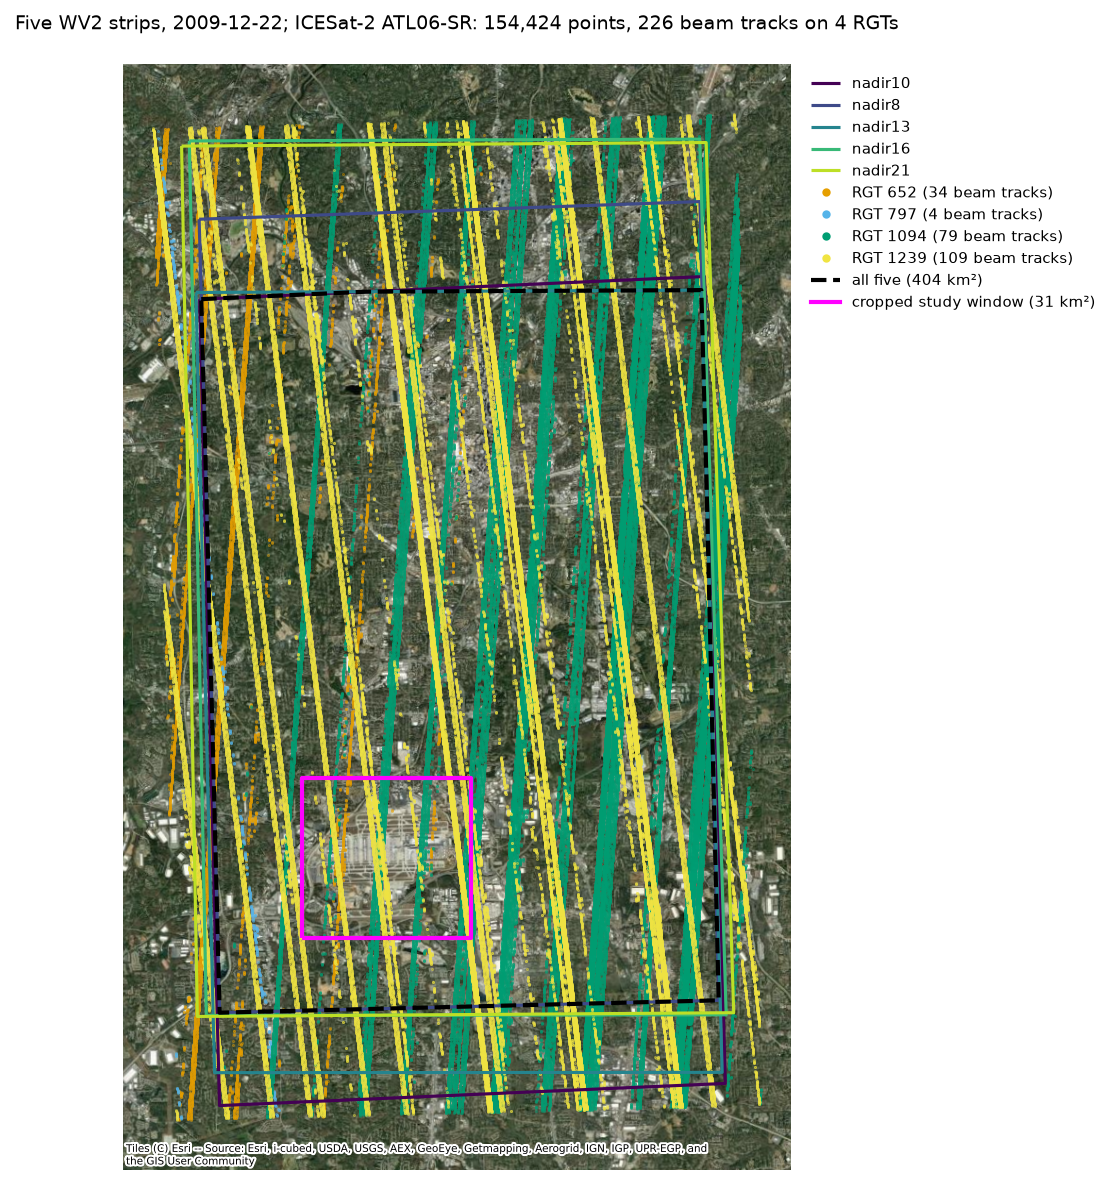

In [2]:
import contextily as ctx
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely import union_all
from shapely.geometry import Polygon, box


def tile_polygon(xml):
    s = open(xml).read()
    corner = lambda c: (
        float(re.search(f"<{c}LON>([^<]+)<", s).group(1)),
        float(re.search(f"<{c}LAT>([^<]+)<", s).group(1)),
    )
    return Polygon([corner(c) for c in ("UL", "UR", "LR", "LL")])


utm = "EPSG:32616"
fp = gpd.GeoDataFrame(
    {
        "name": [f"nadir{SCENES[c]}" for c in SCENES],
        "geometry": [
            union_all([tile_polygon(x) for x in glob(f"{tiles_dir}{c}/{c}_P1BS_P00?.xml")])
            for c in SCENES
        ],
    },
    crs="EPSG:4326",
).to_crs(utm)
common = gpd.GeoSeries([fp.geometry.intersection_all()], crs=utm)
crop = gpd.GeoSeries([box(735685, 3722295, 741350, 3727695)], crs=utm)

atl = gpd.read_parquet(f"{directory}atl06sr_all.parquet").to_crs(utm)
n_tracks = atl.groupby(["rgt", "cycle", "spot"]).ngroups

fig, ax = plt.subplots(figsize=(9, 8), dpi=150)
for (_, r), color in zip(fp.iterrows(), plt.cm.viridis(np.linspace(0, 0.9, len(fp)))):
    gpd.GeoSeries([r.geometry], crs=utm).boundary.plot(ax=ax, color=color, lw=1.5, label=r["name"], zorder=3)
common.boundary.plot(ax=ax, color="k", lw=2, ls="--", zorder=4)
crop.boundary.plot(ax=ax, color="magenta", lw=2, zorder=4)
for rgt, color in zip(sorted(atl.rgt.unique()), ["#e69f00", "#56b4e9", "#009e73", "#f0e442"]):
    sub = atl[atl.rgt == rgt]
    sub.plot(ax=ax, color=color, markersize=0.2, alpha=0.5, zorder=2)
    ax.plot([], [], ".", color=color, label=f"RGT {rgt} ({sub.groupby(['cycle', 'spot']).ngroups} beam tracks)")
ax.plot([], [], "k--", lw=2, label=f"all five ({common.area.iloc[0] / 1e6:.0f} km²)")
ax.plot([], [], color="magenta", lw=2, label=f"cropped study window ({crop.area.iloc[0] / 1e6:.0f} km²)")
ctx.add_basemap(ax, crs=utm, source=ctx.providers.Esri.WorldImagery, attribution_size=5)
ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False)
ax.set_title(
    f"Five WV2 strips, 2009-12-22; ICESat-2 ATL06-SR: {len(atl):,} points, "
    f"{n_tracks} beam tracks on {atl.rgt.nunique()} RGTs",
    fontsize=9,
)
ax.set_axis_off()
fig.tight_layout()

pd.DataFrame(
    {"area (km²)": [g.area / 1e6 for g in fp.geometry]}, index=fp["name"]
).round(0).T

---

## Bundle adjustment

One `bundle_adjust` of the five full strips, the camera network that every stereo run below shares, with the cropped study's settings except for the number of interest points. That study adjusted single tiles with `--ip-per-image 10000`; a strip is three tiles, so `--ip-per-image 30000` keeps the same density per km².

```bash
bundle_adjust -t dg --threads 28 \
    --ip-per-image 30000 --tri-weight 0.1 --tri-robust-threshold 0.1 --camera-weight 0 \
    1030010002B7D800.tif 10300100023BC100.tif 1030010003CAF100.tif 1030010002649200.tif 1030010003127500.tif \
    1030010002B7D800.xml 10300100023BC100.xml 1030010003CAF100.xml 1030010002649200.xml 1030010003127500.xml \
    -o ba/run
```

It took 70 minutes on one 28-core Broadwell node; the median reprojection error after adjustment is 0.20–0.21 px for every camera (0.21 px in the cropped study).

The convergence angles over the full strips are within 0.7° of the cropped study's, so the experiment keeps its design: ten pairs spread from about 5° to 32°, the same six pairs above 15°, and the same two reference stars.

In [3]:
# ba/run-convergence_angles.txt: left right 25% 50% 75% num_matches (degrees)
conv = pd.read_csv(
    f"{directory}ba/run-convergence_angles.txt",
    sep=r"\s+",
    comment="#",
    names=["left", "right", "p25", "p50", "p75", "num_matches"],
)
for col in ("left", "right"):
    conv[col] = conv[col].str.replace(".tif", "", regex=False).map(SCENES)
conv["pair"] = conv["left"] + "-" + conv["right"]

# The cropped study's convergence (worldview_spacenet_benchmark.ipynb), BA of the single tiles
crop_p50 = {"13-16": 5.12, "16-21": 5.36, "8-10": 5.46, "13-21": 10.51, "13-8": 16.33,
            "8-16": 21.47, "13-10": 21.79, "8-21": 26.83, "10-16": 26.93, "10-21": 32.29}
key = lambda p: p if p in crop_p50 else "-".join(p.split("-")[::-1])
conv["crop p50"] = conv["pair"].map(lambda p: crop_p50[key(p)])
conv = conv.sort_values("p50").reset_index(drop=True)
conv[["pair", "p50", "p25", "p75", "crop p50", "num_matches"]].rename(
    columns={"p50": "convergence (deg)"}
).round(2)

,pair,convergence (deg),p25,p75,crop p50,num_matches
0,13-16,4.51,3.96,5.15,5.12,11432
1,8-10,4.79,4.10,5.51,5.46,11507
2,16-21,5.45,5.37,5.52,5.36,11073
3,13-21,9.93,9.42,10.49,10.51,9948
4,13-8,16.97,16.26,17.65,16.33,10081
5,8-16,21.59,21.48,21.69,21.47,9143
6,13-10,21.79,21.78,21.80,21.79,9616
7,10-16,26.28,25.69,26.93,26.93,6514
8,8-21,27.04,26.85,27.20,26.83,5298
9,10-21,31.72,31.18,32.27,32.29,3995


---

## Processing plan

Staged, as proposed in #207. The first stage is enough to check the three Atlanta rules at strip scale:

| Run | Scenes (reference first) | Tests |
|---|---|---|
| ten pairs | every combination | rule 3, the convergence curve |
| MVS 5 ref nadir13 | 13, 8, 10, 16, 21 | rule 1: star 4.5 / 9.9 / 17.0 / 21.8° |
| MVS 5 ref nadir10 | 10, 13, 8, 16, 21 | rule 1: star 4.8 / 21.8 / 26.3 / 31.7° |
| `dem_mosaic` of all ten pairs, of the six > 15°, and `--median` of all ten | | rule 2 |

Each run is made twice:

- **raw** — the cropped study's settings: `parallel_stereo --stereo-algorithm asp_mgm --subpixel-mode 9 --alignment-method affineepipolar --bundle-adjust-prefix ba/run`, then `point2dem --tr 1.9 --t_srs EPSG:32616 --errorimage`;
- **mapprojected** — every strip mapprojected onto the Copernicus GLO-30 DEM (ellipsoid heights) at 0.5 m with the adjusted cameras, then `--alignment-method none`, with the same correlator and gridding. This is the usual recipe for full scenes, and it changes how far a long strip's disparity search has to reach, which a crop barely exercised.

Extra runs from the cropped matrix (MVS 3 and MVS 4 for the scene-count chain, the convergence- and `VerticalStdDev`-weighted blends) wait on the first stage's results.

**Smoke test.** Before the full runs, pair 13-10 was run on the strips but cropped to the cropped study's window, to check that the NAS mosaics, ASP 3.7.0 and the strip-wide bundle adjustment reproduce the laptop result there.